<a href="https://colab.research.google.com/github/Chosencodes/Anatomy-Prior-Guided-Multi-Organ-Segmentation/blob/main/Anatomy_Prior_Guided_Multi_Organ_CT_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Visualize**

In [2]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
root = Path("/content/drive/MyDrive/organ_segmentation_backup")

In [4]:
organs = ["liver", "spleen", "kidney_left", "kidney_right", "pancreas", "stomach", "urinary_bladder"]

patient_id = "s0193"

ct_path = root / patient_id / "ct.nii.gz"
data = nib.load(ct_path)
ct = data.get_fdata()


In [5]:
print("CT shape:", ct.shape)
print("Orientation:", nib.aff2axcodes(data.affine))
print("Voxel spacing:", data.header.get_zooms())

CT shape: (278, 174, 278)
Orientation: ('R', 'A', 'S')
Voxel spacing: (np.float32(1.5), np.float32(1.5), np.float32(1.5))


liver: 429128 voxels
spleen: 30560 voxels
kidney_left: 44827 voxels
kidney_right: 39497 voxels
pancreas: 28991 voxels
stomach: 126661 voxels
urinary_bladder: 29930 voxels


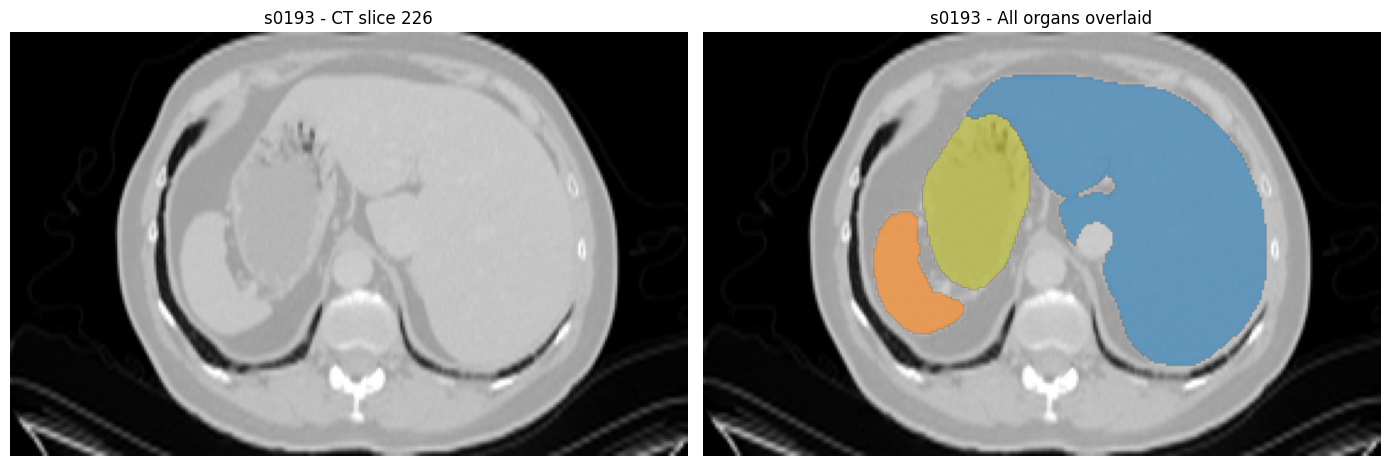

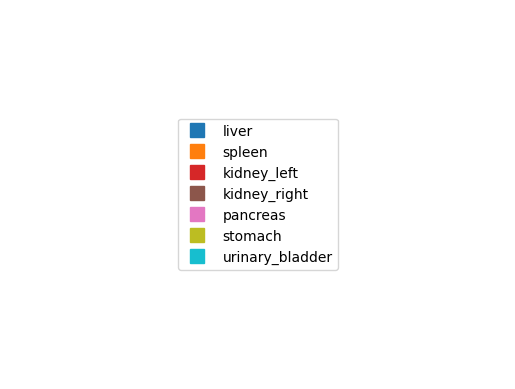

In [6]:
masks = {}
for organ in organs:
    mask_path = root / patient_id / "segmentations" / f"{organ}.nii.gz"
    mask_img = nib.load(mask_path)
    mask_data = mask_img.get_fdata().astype(np.uint8)
    masks[organ] = mask_data
    voxel_count = int(np.sum(mask_data > 0))
    print(f"{organ}: {voxel_count} voxels")

total_per_slice = sum(masks[o].sum(axis=(0, 1)) for o in organs)
z = np.argmax(total_per_slice)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(np.clip(ct[:, :, z], -1000, 400).T, cmap="gray", origin="lower")
axes[0].set_title(f"{patient_id} - CT slice {z}")
axes[0].axis("off")

axes[1].imshow(np.clip(ct[:, :, z], -1000, 400).T, cmap="gray", origin="lower")
colors = plt.cm.tab10(np.linspace(0, 1, len(organs)))
for organ, color in zip(organs, colors):
    mask_slice = masks[organ][:, :, z]
    if mask_slice.sum() > 0:
        overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
        axes[1].imshow(overlay.T, cmap=plt.cm.colors.ListedColormap([color]), alpha=0.6, origin="lower")
axes[1].set_title(f"{patient_id} - All organs overlaid")
axes[1].axis("off")

plt.tight_layout()
plt.show()

for organ, color in zip(organs, colors):
    plt.plot([], [], color=color, marker='s', linestyle='', markersize=10, label=organ)
plt.legend(loc='center')
plt.axis('off')
plt.show()

Best slice per organ: {'liver': np.int64(230), 'spleen': np.int64(219), 'kidney_left': np.int64(165), 'kidney_right': np.int64(156), 'pancreas': np.int64(189), 'stomach': np.int64(226), 'urinary_bladder': np.int64(40)}


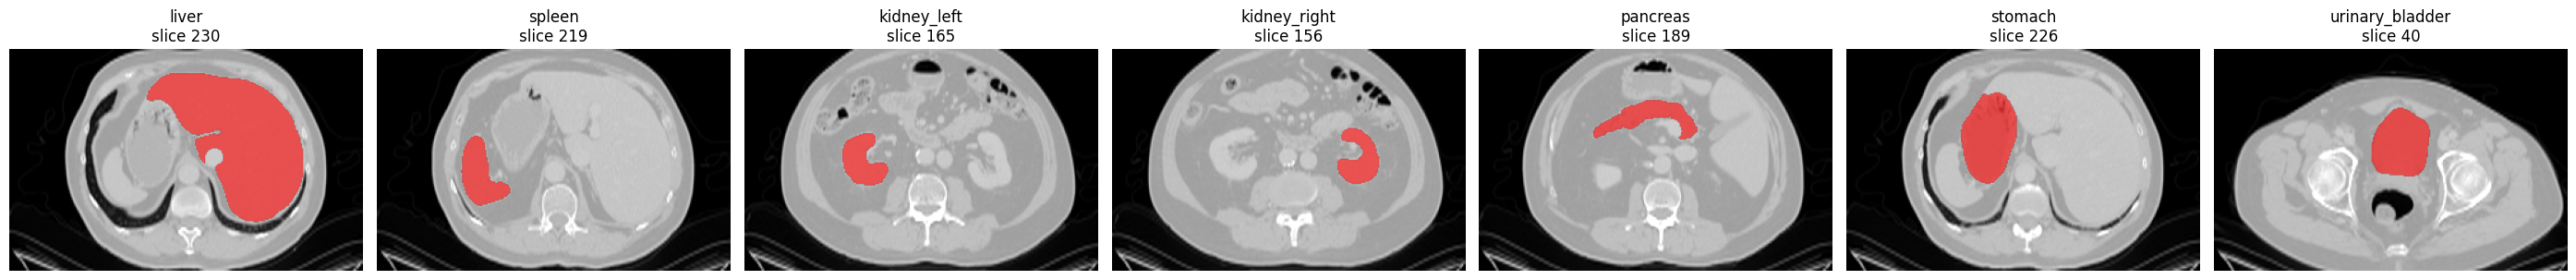

In [7]:
organ_best_slices = {}
for organ in organs:
    per_slice_counts = masks[organ].sum(axis=(0, 1))
    if per_slice_counts.max() > 0:
        organ_best_slices[organ] = np.argmax(per_slice_counts)

print("Best slice per organ:", organ_best_slices)

# plot one slice per organ, each showing just that organ highlighted
fig, axes = plt.subplots(1, len(organ_best_slices), figsize=(4*len(organ_best_slices), 5))

for ax, (organ, z) in zip(axes, organ_best_slices.items()):
    ax.imshow(np.clip(ct[:, :, z], -1000, 400).T, cmap="gray", origin="lower")
    mask_slice = masks[organ][:, :, z]
    overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
    ax.imshow(overlay.T, cmap="autumn", alpha=0.6, origin="lower")
    ax.set_title(f"{organ}\nslice {z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# **Preprocessing**

In [8]:
!pip install torchio nibabel scikit-learn tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.4 MB/s eta 0:00:00


In [9]:
import torch
import torchio as tio
from sklearn.model_selection import train_test_split
from torchio import SubjectsLoader

In [11]:
root = Path("/content/drive/MyDrive/organ_segmentation_backup")

organs = ["liver", "spleen", "kidney_left", "kidney_right", "pancreas", "stomach", "urinary_bladder"]

organ_to_label = {organ: i + 1 for i, organ in enumerate(organs)}
print(organ_to_label)

{'liver': 1, 'spleen': 2, 'kidney_left': 3, 'kidney_right': 4, 'pancreas': 5, 'stomach': 6, 'urinary_bladder': 7}
